Análisis Exploratorio de Datos (EDA)
En este notebook realizamos un análisis profundo del comportamiento de los usuarios mediante 5 visualizaciones seleccionadas (2 univariadas, 2 bivariadas y 1 multivariada), orientadas a entender el consumo de la plataforma.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Cargar el dataset procesado en la etapa anterior
df = pd.read_json("../data/processed/streaming_users_clean.json")
df.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crime,2025-03-04,99
1,10001,37,Estándar,1173.4,Colombia,Crime,2019-04-02,2
2,10002,28,Básico,401.0,Colombia,Crime,2018-04-13,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1


 Gráfico 1 (Univariado): Distribución de `monthly_watch_time_mins`
**Objetivo:** Analizar cómo se distribuye el tiempo mensual de visualización entre los usuarios para identificar si el consumo es homogéneo o si está concentrado.

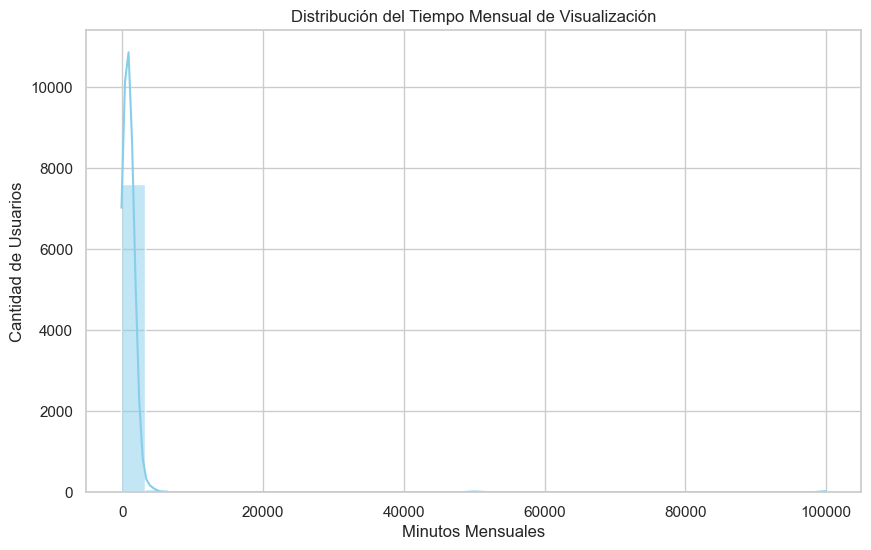

In [2]:
sns.histplot(data=df, x='monthly_watch_time_mins', kde=True, color='skyblue', bins=30)
plt.title('Distribución del Tiempo Mensual de Visualización')
plt.xlabel('Minutos Mensuales')
plt.ylabel('Cantidad de Usuarios')
plt.show()

**Interpretación:** El histograma permite observar la concentración de usuarios según su nivel de actividad mensual. La curva de densidad (KDE) nos ayuda a detectar sesgos en el consumo, identificando si la mayoría de la audiencia es de consumo moderado o si existen grupos de "maratonear" intensivo.

 Gráfico 2 (Univariado): Distribución de `favorite_genre`
**Objetivo:** Identificar cuáles son los géneros de contenido más populares y evaluar el peso de la categoría "Unknown" que imputamos.

C:\Users\Estudiante\AppData\Local\Temp\ipykernel_10216\3516843628.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='favorite_genre', order=order, palette='viridis')


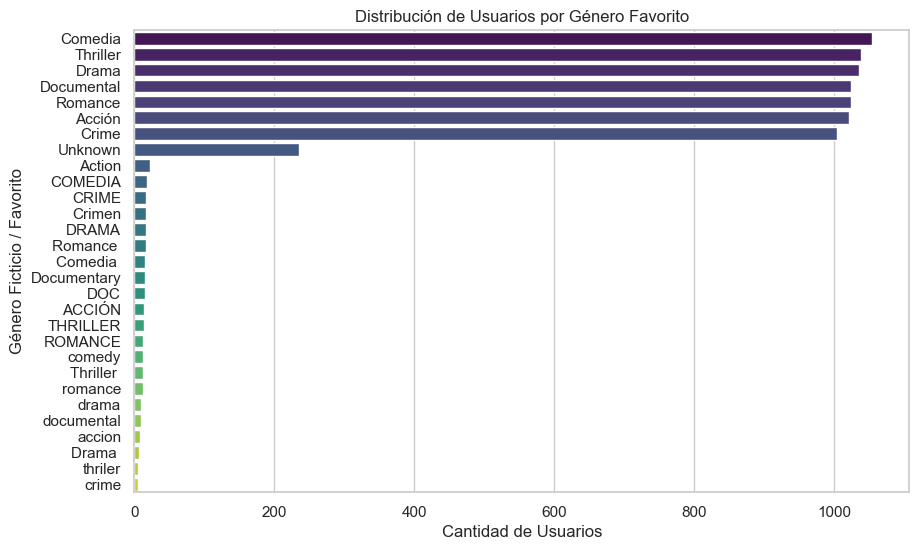

In [3]:
order = df['favorite_genre'].value_counts().index
sns.countplot(data=df, y='favorite_genre', order=order, palette='viridis')
plt.title('Distribución de Usuarios por Género Favorito')
plt.xlabel('Cantidad de Usuarios')
plt.ylabel('Género Ficticio / Favorito')
plt.show()

**Interpretación:** Este gráfico de barras horizontales revela las preferencias de la audiencia. Permite dimensionar la participación de cada género en el mercado y comprobar que la categoría "Unknown" (nulos imputados) no altere el liderazgo de los géneros principales.

 Gráfico 3 (Bivariado): Tiempo de Visualización vs. Género Favorito
**Objetivo:** Determinar si el género favorito de los usuarios influye en la cantidad de minutos mensuales que pasan consumiendo contenido.

C:\Users\Estudiante\AppData\Local\Temp\ipykernel_10216\120636841.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='monthly_watch_time_mins', y='favorite_genre', palette='Set2')


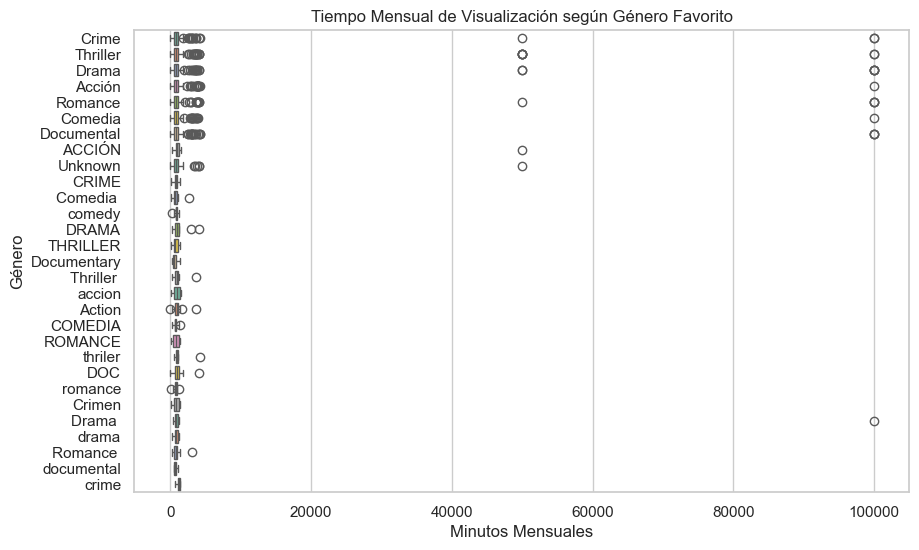

In [4]:
sns.boxplot(data=df, x='monthly_watch_time_mins', y='favorite_genre', palette='Set2')
plt.title('Tiempo Mensual de Visualización según Género Favorito')
plt.xlabel('Minutos Mensuales')
plt.ylabel('Género')
plt.show()

**Interpretación:** El gráfico de caja (Boxplot) compara las medianas y la dispersión del tiempo de consumo entre géneros. Nos permite comprobar de manera visual si algún género en particular retiene a los usuarios por más tiempo o si el comportamiento es similar en todo el catálogo.

 Gráfico 4 (Bivariado): Matriz de Correlación
**Objetivo:** Evaluar la intensidad y dirección de las relaciones lineales entre todas las variables numéricas del dataset.

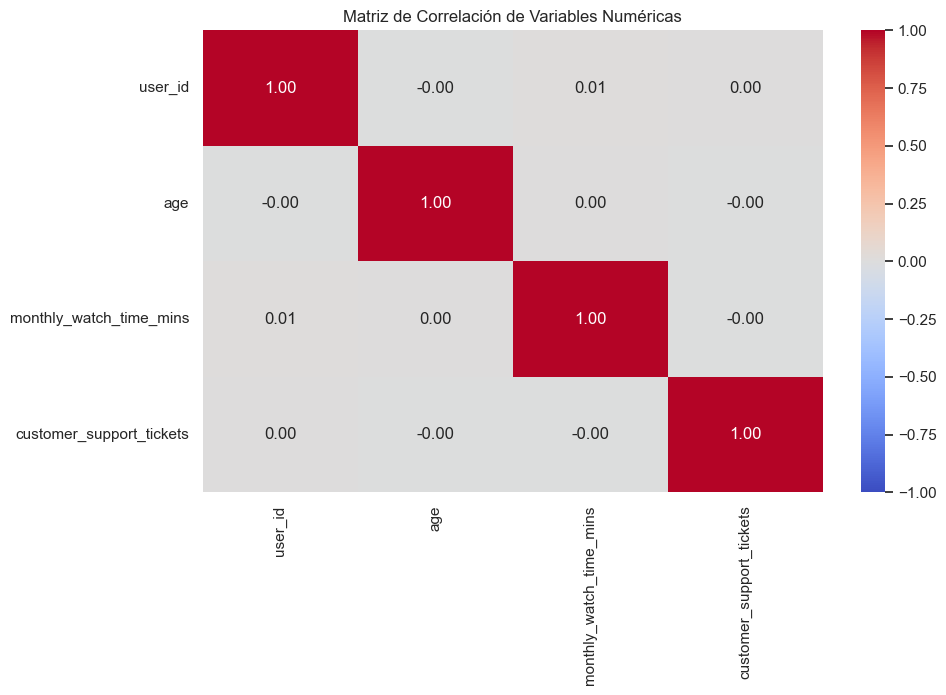

In [5]:
# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

**Interpretación:** El mapa de calor identifica qué variables numéricas se mueven juntas. Un valor cercano a 1 implicaría una fuerte relación positiva, clave para entender qué métricas de comportamiento están asociadas directamente con el engagement.

 Gráfico 5 (Multivariado): Pairplot de Variables Clave segmentado por Género
**Objetivo:** Analizar de forma simultánea las distribuciones y cruces de las principales variables numéricas, separando los comportamientos según los géneros principales.

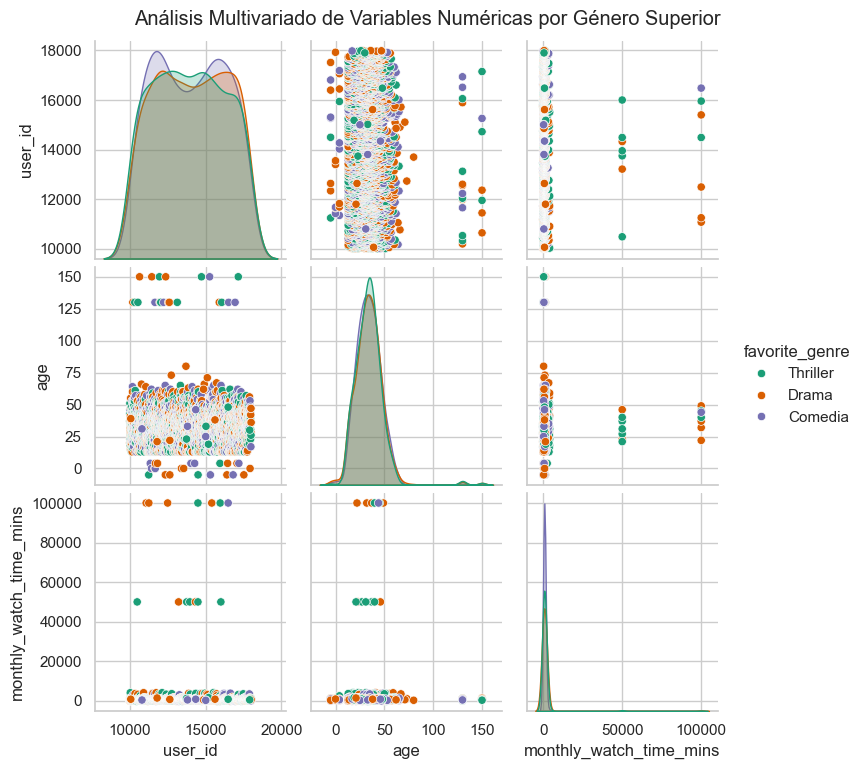

In [6]:
# Seleccionamos las columnas numéricas principales y el género para segmentar
# Filtramos los 3 géneros más comunes para evitar que el gráfico quede sobrecargado
top_genres = df['favorite_genre'].value_counts().nlargest(3).index
df_filtered = df[df['favorite_genre'].isin(top_genres)]

# Creamos el pairplot (elegimos un par de variables numéricas para el ejemplo)
num_vars = numeric_cols.columns[:3].tolist() # toma las primeras 3 numéricas
if len(num_vars) >= 2:
    sns.pairplot(data=df_filtered, vars=num_vars, hue='favorite_genre', palette='Dark2')
    plt.suptitle('Análisis Multivariado de Variables Numéricas por Género Superior', y=1.02)
    plt.show()
else:
    print("Se requieren al menos 2 variables numéricas para construir el pairplot.")

**Interpretación:** Este análisis multivariado nos permite observar cómo interactúan múltiples métricas a la vez y si los usuarios forman "clusters" o agrupaciones visuales naturales según el tipo de contenido que prefieren.